<a href="https://colab.research.google.com/github/jeetb270/Stratify_2026_Dark_Matter/blob/main/stratify_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTING LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# READING DATA

cand_sites = pd.read_csv("Data/candidate_sites.csv")
order_log = pd.read_csv("Data/order_log.csv")
pincode_den = pd.read_csv("Data/pincode_density.csv")
store_master = pd.read_csv("Data/store_master.csv")
data_dict = pd.read_csv("Data/data_dictionary.csv")

# Understand data format to clean the data

print("Candidate Sites:\n", cand_sites.head())
print("\nOrder Logs:\n", order_log.head())
print("\nPincode Density:\n", pincode_den.head())
print("\nStore Master:\n", store_master.head())
print("\nData Dictionary:\n", data_dict.head())

Candidate Sites:
   site_id  city  site_lat  site_lon  site_pincode  carpet_area_sqft  \
0   CS-01  Pune   18.5975    73.764        411057              2650   
1   CS-02  Pune   18.5760    73.770        411045              2400   
2   CS-03  Pune   18.4670    73.888        411048              2900   
3   CS-04  Pune   18.5090    73.813        411038              2200   
4   CS-05  Pune   18.5640    73.908        411014              2050   

   monthly_rent_inr  one_time_fitout_cost_inr  
0             82000                   1650000  
1             76000                   1480000  
2             64000                   1520000  
3             88000                   1390000  
4             79000                   1310000  

Order Logs:
      order_id      order_timestamp       city store_id  delivery_pincode  \
0  ORD0000001  2026-04-01 00:14:29       Pune   PUN-07            411057   
1  ORD0000002  2026-04-01 00:15:20       Pune   PUN-01            411058   
2  ORD0000003  2026-04-01

In [ ]:
# CLEANING DATA

# Convert date and time columns to datetime objects
order_log['order_timestamp'] = pd.to_datetime(order_log['order_timestamp'])
store_master['go_live_date'] = pd.to_datetime(store_master['go_live_date'])


# Extract the month from the order timestamp for monthly fixed cost calculations later
order_log['order_month'] = order_log['order_timestamp'].dt.to_period('M')


# Create a breach flag: True if actual_delivery_min > promised_delivery_min
order_log['breach'] = order_log['actual_delivery_min'] > order_log['promised_delivery_min']


# Drop any potential duplicates in the order log
order_log = order_log.drop_duplicates(subset=['order_id'])


# Drop orders containing missing values
order_log = order_log.dropna(subset=['order_id', 'delivery_lat', 'delivery_lon', 'store_id', 'actual_delivery_min'])


print("Data cleaning completed.")
print(order_log[['order_id', 'order_timestamp', 'breach']].head())

Data cleaning completed.
     order_id     order_timestamp  breach
0  ORD0000001 2026-04-01 00:14:29   False
1  ORD0000002 2026-04-01 00:15:20   False
2  ORD0000003 2026-04-01 00:27:56   False
3  ORD0000004 2026-04-01 00:28:20   False
4  ORD0000005 2026-04-01 00:28:39   False


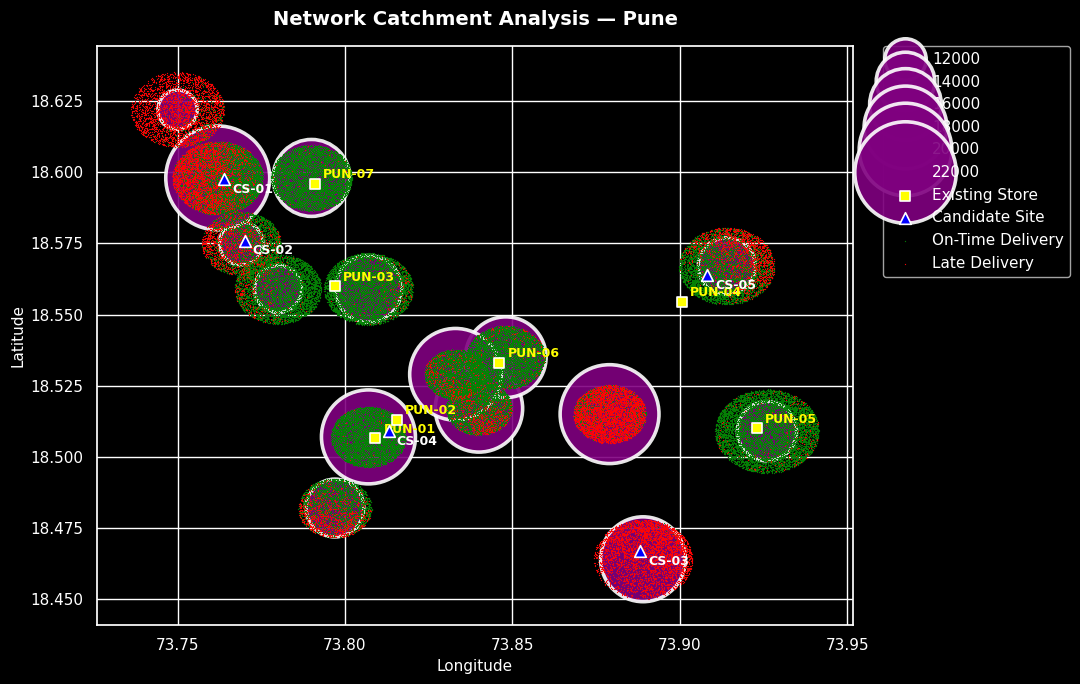

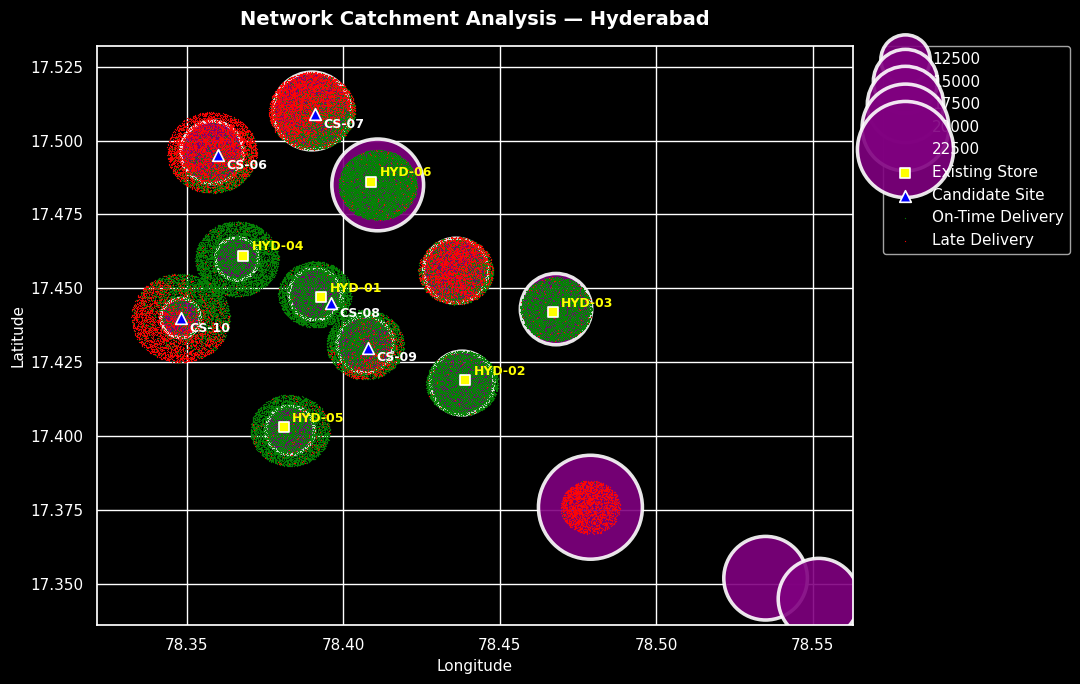

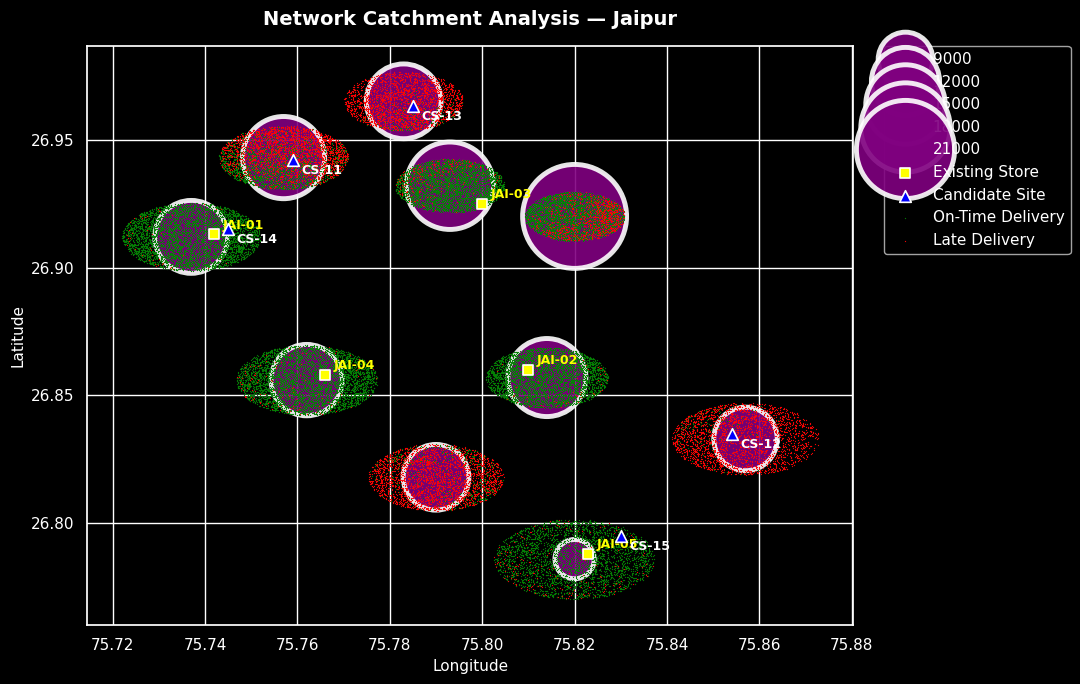

In [ ]:
# CREATING A VISUAL

# Set the plot style
sns.set_theme(style="darkgrid")
plt.style.use('dark_background')

cities = ['Pune', 'Hyderabad', 'Jaipur']

for city in cities:
    # Filter datasets by city
    city_pincodes = pincode_den[pincode_den['city'] == city]
    city_stores = store_master[store_master['city'] == city]
    city_candidates = cand_sites[cand_sites['city'] == city]
    city_orders = order_log[order_log['city'] == city]

    plt.figure(figsize=(11, 7))

    # Pincode Centroids (Bubble size = Population Density)
    sns.scatterplot(
        data=city_pincodes,
        x='pincode_centroid_lon',
        y='pincode_centroid_lat',
        size='population_density_per_sqkm',
        sizes=(800, 5600),
        alpha=0.90,
        color='purple',
        legend='brief'
    )

    # Existing Active Dark Stores
    plt.scatter(
        city_stores['store_lon'],
        city_stores['store_lat'],
        color='yellow',
        marker='s',        # Square
        s=60,
        edgecolor='white',
        linewidth=1.2,
        zorder=5,
        label='Existing Store'
    )

    # Candidate Dark Store Sites
    plt.scatter(
        city_candidates['site_lon'],
        city_candidates['site_lat'],
        color='blue',
        marker='^',        # Triangle
        s=70,
        edgecolor='white',
        linewidth=1.2,
        zorder=5,
        label='Candidate Site'
    )

    # Order Locations
    on_time = city_orders[city_orders['actual_delivery_min'] <= city_orders['promised_delivery_min']]
    delayed = city_orders[city_orders['actual_delivery_min'] > city_orders['promised_delivery_min']]

    plt.scatter(
        on_time['delivery_lon'],
        on_time['delivery_lat'],
        s=0.75,
        color='green',
        edgecolor='white',
        linewidth=0.01,
        zorder=1,
        label='On-Time Delivery'
    )

    plt.scatter(
        delayed['delivery_lon'],
        delayed['delivery_lat'],
        s=0.75,
        color='red',
        edgecolor='white',
        linewidth=0.01,
        zorder=1,
        label='Late Delivery'
    )

    # Annotate Store IDs
    for _, row in city_stores.iterrows():
        plt.annotate(
            row['store_id'],
            (row['store_lon'], row['store_lat']),
            fontsize=9, fontweight='bold', color='yellow',
            xytext=(6, 4), textcoords='offset points'
        )

    # Annotate Candidate Site IDs
    for _, row in city_candidates.iterrows():
        plt.annotate(
            row['site_id'],
            (row['site_lon'], row['site_lat']),
            fontsize=9, fontweight='bold', color='white',
            xytext=(6, -10), textcoords='offset points'
        )

    # Styling and Labels
    plt.title(f'Network Catchment Analysis — {city}', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Longitude', fontsize=11)
    plt.ylabel('Latitude', fontsize=11)

    # Place legend outside plot area
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", borderaxespad=0)
    plt.tight_layout()

    plt.show()

In [ ]:
# KEY TASK 1:

cost_to_serve = pd.merge(order_log, store_master, on = ['store_id', 'city'], how = 'left')

cost_to_serve['no_of_orders'] = cost_to_serve.groupby(['store_id', 'order_month'])['order_id'].transform('count')

# Vectorized Distance Calculation
lat = cost_to_serve['delivery_lat'] - cost_to_serve['store_lat']
lon = cost_to_serve['delivery_lon'] - cost_to_serve['store_lon']
lat_mean = (cost_to_serve['delivery_lat'] + cost_to_serve['store_lat']) / 2.0

cost_to_serve['distance'] = np.sqrt(
    (lat * 111.0) ** 2 +
    (lon * 111.0 * np.cos(np.radians(lat_mean))) ** 2
)

# Fixed cost for every order
rider_base_payout = 22.0
packaging_cost = 8.0

# Vectorized Cost Allocation
breach_penalty = np.where(cost_to_serve['breach'] == True, 30.0, 0.0)

# Total monthly store overhead divided by orders fulfilled by that store in that month
fixed_cost_per_order = (
    cost_to_serve['monthly_rent_inr'] + cost_to_serve['monthly_fixed_cost_inr']
) / cost_to_serve['no_of_orders']

# Combine all components into final cost vector
cost_to_serve['cost'] = rider_base_payout + packaging_cost + (7.0 * cost_to_serve['distance']) + breach_penalty + fixed_cost_per_order

print(cost_to_serve.head())

     order_id     order_timestamp       city store_id  delivery_pincode  \
0  ORD0000001 2026-04-01 00:14:29       Pune   PUN-07            411057   
1  ORD0000002 2026-04-01 00:15:20       Pune   PUN-01            411058   
2  ORD0000003 2026-04-01 00:27:56  Hyderabad   HYD-04            500032   
3  ORD0000004 2026-04-01 00:28:20       Pune   PUN-03            411021   
4  ORD0000005 2026-04-01 00:28:39  Hyderabad   HYD-06            500049   

   delivery_lat  delivery_lon  basket_value_inr  promised_delivery_min  \
0     18.594295     73.771084            528.93                     10   
1     18.478135     73.801242            308.24                     10   
2     17.431143     78.337979            357.72                     10   
3     18.553791     73.768771            574.25                     10   
4     17.501828     78.388093            250.99                     10   

   actual_delivery_min  ... breach  store_lat  store_lon  store_pincode  \
0                 2.81  ...  

In [ ]:
# KEY TASK 2:

# Grouping orders based on their distance from the dark stores
cost_to_serve['group'] = np.ceil(cost_to_serve['distance'] / 0.5)

# Aggregate total orders and breaches by store_id and group
grouped = cost_to_serve.groupby(['store_id', 'group'])['breach'].agg(
    total_orders='count',
    breach_count='sum'
).reset_index()

# Reindex/Fill missing groups per store to ensure unbroken distance steps
all_stores = grouped['store_id'].unique()
max_group = int(grouped['group'].dropna().max())
full_index = pd.MultiIndex.from_product([all_stores, range(1, max_group + 1)], names=['store_id', 'group'])

grouped = grouped.set_index(['store_id', 'group']).reindex(full_index, fill_value=0).reset_index()

# Sort and calculate cumulative totals
grouped = grouped.sort_values(['store_id', 'group'])
grouped['cum_orders'] = grouped.groupby('store_id')['total_orders'].cumsum()
grouped['cum_breaches'] = grouped.groupby('store_id')['breach_count'].cumsum()

# Calculate cumulative breach rate
grouped['cum_breach_rate'] = np.where(
    grouped['cum_orders'] > 0,
    grouped['cum_breaches'] / grouped['cum_orders'],
    0.0
)

# Filter for groups reaching >= 20% breach rate
breach_threshold_met = grouped[grouped['cum_breach_rate'] >= 0.2]

# Extract the FIRST group hitting threshold per store and calculate radius
first_breach_group = breach_threshold_met.groupby('store_id')['group'].first().reset_index()
first_breach_group['calculated_radius'] = first_breach_group['group'] * 0.5

# Merge using the unique temporary column name 'calculated_radius'
cost_to_serve = cost_to_serve.merge(
    first_breach_group[['store_id', 'calculated_radius']],
    on='store_id',
    how='left'
)

# Calculate dynamic fallback for stores that never hit 20% breach
max_group_per_store = cost_to_serve.groupby('store_id')['group'].transform('max')
fallback_radius = -1.0 * (0.5 * max_group_per_store)

# Assign directly to final 'service_radius' column
cost_to_serve['service_radius'] = cost_to_serve['calculated_radius'].fillna(fallback_radius)

# Clean up temporary working column
cost_to_serve.drop(columns=['calculated_radius'], inplace=True)

print(cost_to_serve.head())

     order_id     order_timestamp       city store_id  delivery_pincode  \
0  ORD0000001 2026-04-01 00:14:29       Pune   PUN-07            411057   
1  ORD0000002 2026-04-01 00:15:20       Pune   PUN-01            411058   
2  ORD0000003 2026-04-01 00:27:56  Hyderabad   HYD-04            500032   
3  ORD0000004 2026-04-01 00:28:20       Pune   PUN-03            411021   
4  ORD0000005 2026-04-01 00:28:39  Hyderabad   HYD-06            500049   

   delivery_lat  delivery_lon  basket_value_inr  promised_delivery_min  \
0     18.594295     73.771084            528.93                     10   
1     18.478135     73.801242            308.24                     10   
2     17.431143     78.337979            357.72                     10   
3     18.553791     73.768771            574.25                     10   
4     17.501828     78.388093            250.99                     10   

   actual_delivery_min  ... store_lon  store_pincode  monthly_rent_inr  \
0                 2.81  ...   

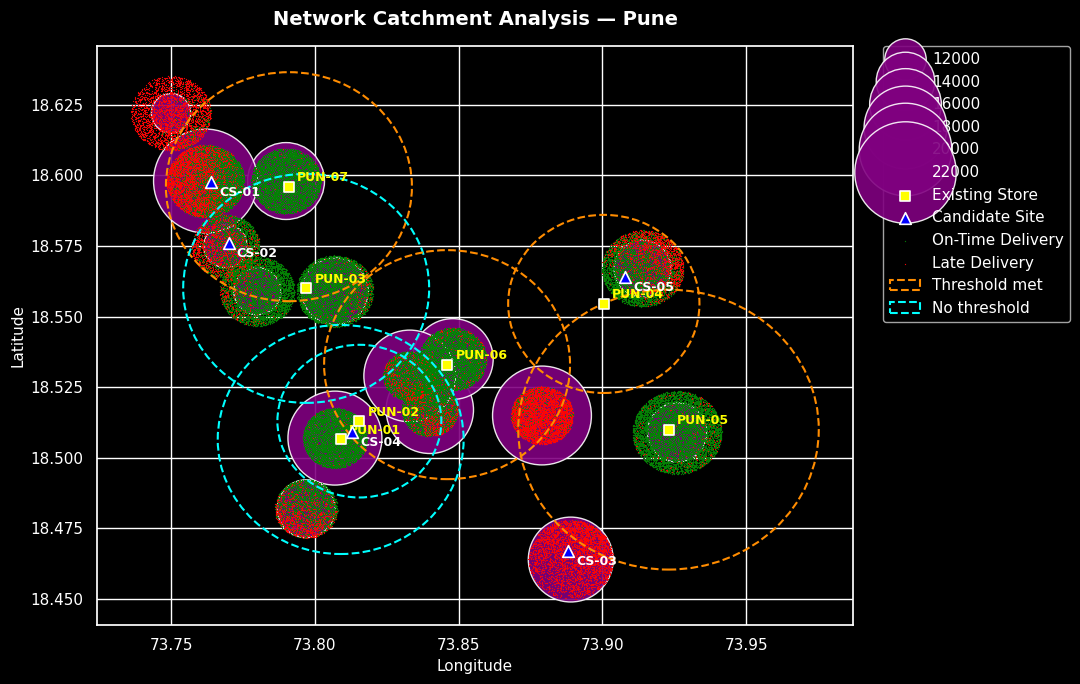

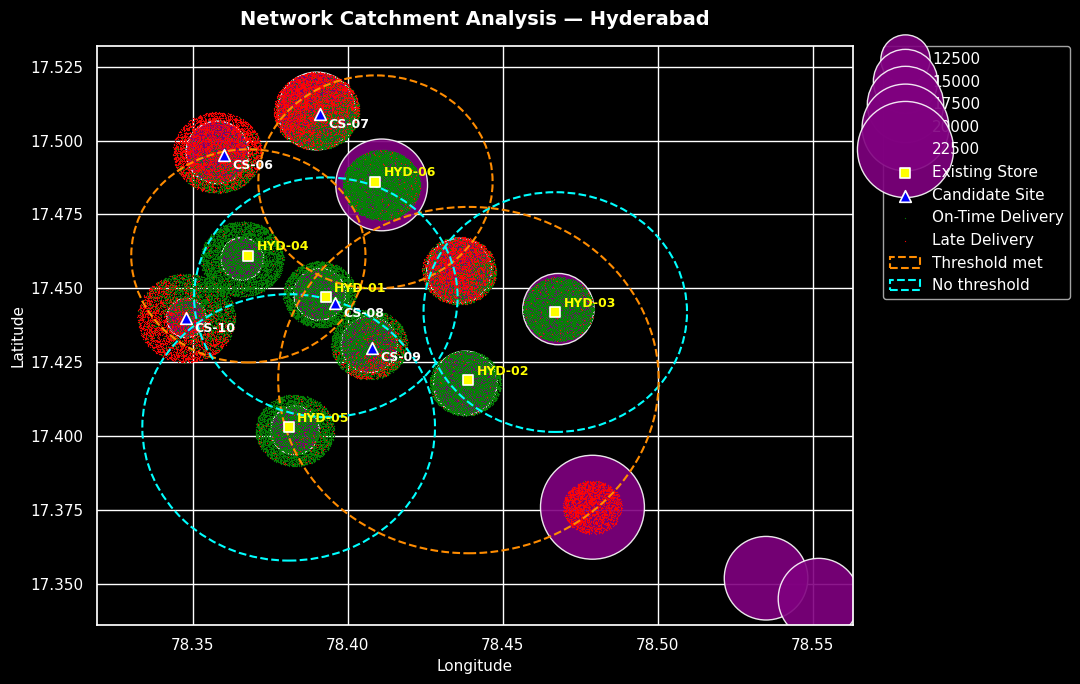

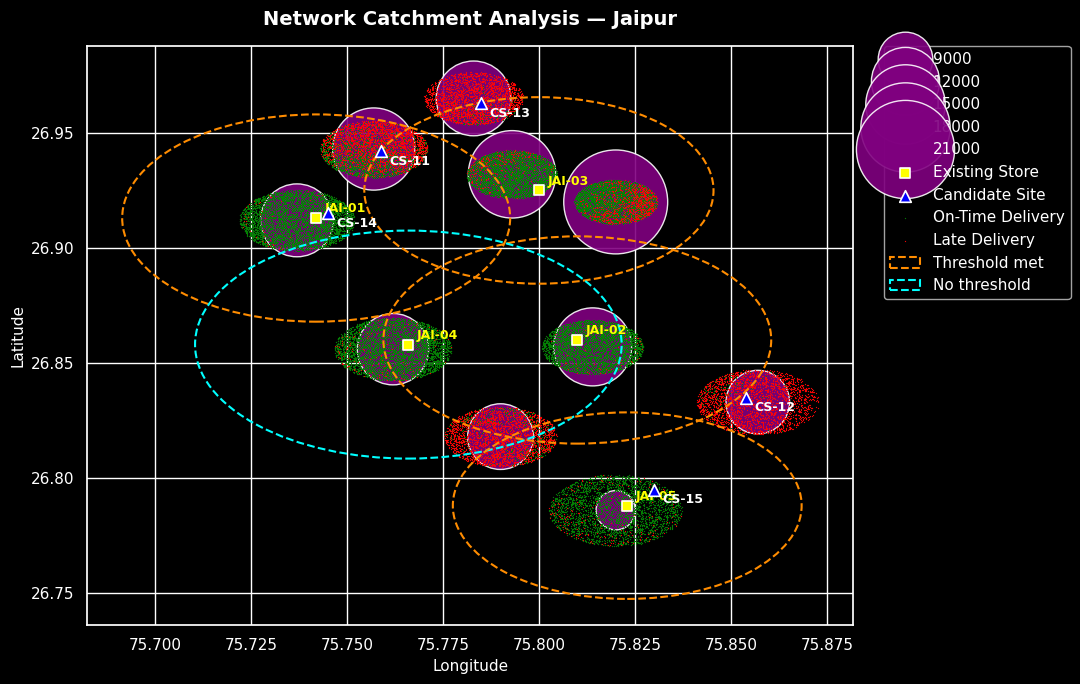

In [ ]:
# VISUAL WITH SERVICE RADIUS

from matplotlib.patches import Ellipse

# Set the plot style
sns.set_theme(style="darkgrid")
plt.style.use('dark_background')

# Cities in scope
cities = ['Pune', 'Hyderabad', 'Jaipur']

for city in cities:
    # Filter datasets by city
    city_pincodes = pincode_den[pincode_den['city'] == city]
    city_stores = store_master[store_master['city'] == city]
    city_candidates = cand_sites[cand_sites['city'] == city]
    city_orders = order_log[order_log['city'] == city]
    city_cts = cost_to_serve[cost_to_serve['city'] == city]

    plt.figure(figsize=(11, 7))

    # Pincode Centroids (Bubble size = Population Density)
    sns.scatterplot(
        data=city_pincodes,
        x='pincode_centroid_lon',
        y='pincode_centroid_lat',
        size='population_density_per_sqkm',
        sizes=(800, 5600),
        alpha=0.90,
        color='purple',
        linewidth=1,
        legend='brief'
    )

    # Existing Active Dark Stores
    plt.scatter(
        city_stores['store_lon'],
        city_stores['store_lat'],
        color='yellow',
        marker='s',        # Square
        s=60,
        edgecolor='white',
        linewidth=1.2,
        zorder=5,
        label='Existing Store'
    )

    # Candidate Dark Store Sites
    plt.scatter(
        city_candidates['site_lon'],
        city_candidates['site_lat'],
        color='blue',
        marker='^',        # Triangle
        s=70,
        edgecolor='white',
        linewidth=1.2,
        zorder=5,
        label='Candidate Site'
    )

    # Order Locations
    on_time = city_orders[city_orders['actual_delivery_min'] <= city_orders['promised_delivery_min']]
    delayed = city_orders[city_orders['actual_delivery_min'] > city_orders['promised_delivery_min']]

    plt.scatter(
        on_time['delivery_lon'],
        on_time['delivery_lat'],
        s=0.75,
        color='green',
        edgecolor='white',
        linewidth=0.01,
        zorder=1,
        label='On-Time Delivery'
    )

    plt.scatter(
        delayed['delivery_lon'],
        delayed['delivery_lat'],
        s=0.75,
        color='red',
        edgecolor='white',
        linewidth=0.01,
        zorder=1,
        label='Late Delivery'
    )

    # Extract just the unique stores and their radii to prevent duplicate drawing
    store_radii = city_cts[['store_id', 'store_lat', 'store_lon', 'service_radius']].drop_duplicates()

    # Get the current Axes object to add patches to
    ax = plt.gca()

    # Draw the catchment area for each unique store
    red = False
    blue = False
    for _, row in store_radii.iterrows():
        lat = row['store_lat']
        lon = row['store_lon']
        radius_km = row['service_radius']

        if radius_km > 0:
            # Reached threshold: Red
            r_km = radius_km
            color = 'darkorange'
            label = 'Threshold met' if not red else None
            red = True
        else:
            # Fallback (never reached 20%): Blue
            r_km = abs(radius_km)
            color = 'cyan'
            label = 'No threshold' if not blue else None
            blue = True

        # Radius Conversion
        lat_radius_deg = r_km / 111.0
        lon_radius_deg = r_km / (111.0 * np.cos(np.radians(lat)))

        # Create an Ellipse to represent the true circular area on a flat grid
        # width = x-axis diameter (longitude span)
        # height = y-axis diameter (latitude span)
        catchment_area = Ellipse(
            xy=(lon, lat),
            width=lon_radius_deg * 2,
            height=lat_radius_deg * 2,
            color=color,
            fill=False,
            linewidth=1.5,
            linestyle='--',
            label = label
        )

        # Add the patch to the plot
        ax.add_patch(catchment_area)

    # Annotate Store IDs
    for _, row in city_stores.iterrows():
        plt.annotate(
            row['store_id'],
            (row['store_lon'], row['store_lat']),
            fontsize=9, fontweight='bold', color='yellow',
            xytext=(6, 4), textcoords='offset points'
        )

    # Annotate Candidate Site IDs
    for _, row in city_candidates.iterrows():
        plt.annotate(
            row['site_id'],
            (row['site_lon'], row['site_lat']),
            fontsize=9, fontweight='bold', color='white',
            xytext=(6, -10), textcoords='offset points'
        )

    # Styling and Labels
    plt.title(f'Network Catchment Analysis — {city}', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Longitude', fontsize=11)
    plt.ylabel('Latitude', fontsize=11)

    # Place legend outside plot area
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", borderaxespad=0)
    plt.tight_layout()

    plt.show()

In [ ]:
# KEY TASK 3:

# All breached orders outside the service radii of all stores
uncovered_orders = cost_to_serve[
    (cost_to_serve['breach'] == True) &
    (cost_to_serve['distance'] > cost_to_serve['service_radius'])
].copy()

# All stores with their service radii
unique_stores = cost_to_serve[['store_id', 'service_radius']].drop_duplicates()

# Calculating Average Service Radius for future approximations
average_radius = unique_stores['service_radius'].abs().mean()

# Finds the nearest Candidate Site
def assign_to_nearest_candidate(row, candidates_df):
    """Calculates flat-grid distance to all candidates and returns the closest."""
    lat_diff = candidates_df['site_lat'] - row['delivery_lat']
    lon_diff = candidates_df['site_lon'] - row['delivery_lon']
    lat_mean = (candidates_df['site_lat'] + row['delivery_lat']) / 2.0

    distances = np.sqrt(
        (lat_diff * 111.0)**2 +
        (lon_diff * 111.0 * np.cos(np.radians(lat_mean)))**2
    )

    nearest_idx = distances.idxmin()
    return candidates_df.loc[nearest_idx, 'site_id'], distances.min()

# Assigns nearest Candidate Site to uncovered orders
uncovered_orders[['nearest_site_id', 'distance_to_site']] = uncovered_orders.apply(
    lambda r: pd.Series(assign_to_nearest_candidate(r, cand_sites[cand_sites['city'] == r['city']])),
    axis=1
)

# Calculating capturable demand based on the approximation that all orders in radius 0.75*average_radius are covered
capturable_demand = uncovered_orders[uncovered_orders['distance_to_site'] <= average_radius*0.75]

# Calculating potential of Candidate Site based on capturable demand
site_potential = capturable_demand.groupby('nearest_site_id').size().reset_index(name='potential_order_volume')
site_potential = site_potential.merge(cand_sites[['site_id', 'monthly_rent_inr']], left_on='nearest_site_id', right_on='site_id')
site_potential['implied_fixed_cost_per_order'] = site_potential['monthly_rent_inr'] / site_potential['potential_order_volume']

site_potential = site_potential.sort_values(by='potential_order_volume', ascending=False)
print("Top Candidate Sites by Uncovered Demand Capture:")
print(site_potential)

# Calculating on-time delivery orders by existing stores
store_real_volume = (
    cost_to_serve.groupby("store_id")["order_id"]
    .count()
    .reset_index(name="real_order_volume")
)

# Pairing existing stores with each other and calculating distance between them
stores_cross = store_master.merge(store_master, on='city', suffixes=('_a', '_b'))
stores_cross = stores_cross[stores_cross['store_id_a'] != stores_cross['store_id_b']]

lat_mean_stores = (stores_cross['store_lat_a'] + stores_cross['store_lat_b']) / 2.0
stores_cross['store_distance'] = np.sqrt(
    ((stores_cross['store_lat_a'] - stores_cross['store_lat_b']) * 111.0)**2 +
    ((stores_cross['store_lon_a'] - stores_cross['store_lon_b']) * 111.0 * np.cos(np.radians(lat_mean_stores)))**2
)

# Finding cannibalized pairs of stores based on the approximation distance < average_radiius*0.5
cannibalized_pairs = stores_cross[stores_cross['store_distance'] < average_radius*0.5].copy()

# Adding order volume to cannibalized_pairs
cannibalized_pairs = cannibalized_pairs.merge(
    store_real_volume.rename(columns={'store_id': 'store_id_a', 'real_order_volume': 'volume_a'}),
    on='store_id_a',
    how='left'
)
cannibalized_pairs = cannibalized_pairs.merge(
    store_real_volume.rename(columns={'store_id': 'store_id_b', 'real_order_volume': 'volume_b'}),
    on='store_id_b',
    how='left'
)

# Determining which store to shut down in each pair
cannibalized_pairs['Shut_Down'] = np.where(
    cannibalized_pairs['volume_a'] < cannibalized_pairs['volume_b'],
    cannibalized_pairs['store_id_a'],
    cannibalized_pairs['store_id_b']
)

print(f"\nStores Flagged for Potential Closure/Relocation (Distance < {average_radius*0.5:.2f}km):")
print(cannibalized_pairs[
    ['city', 'store_id_a', 'store_id_b', 'volume_a', 'volume_b', 'store_distance', 'monthly_rent_inr_a', 'monthly_rent_inr_b', 'Shut_Down']
].drop_duplicates(subset=['store_distance']))

store_real_volume = (
    cost_to_serve.groupby("store_id")["order_id"]
    .count()
    .reset_index(name="real_order_volume")
)

# Pairing Cadidate Sites with existing Stores to determine relocation
reloc_cross = cand_sites.merge(
    store_master, on="city", suffixes=("_cand", "_store")
)

# Calculating distance between the two
lat_mean_reloc = (reloc_cross["site_lat"] + reloc_cross["store_lat"]) / 2.0
reloc_cross["distance_km"] = np.sqrt(
    ((reloc_cross["site_lat"] - reloc_cross["store_lat"]) * 111.0) ** 2
    + (
        (reloc_cross["site_lon"] - reloc_cross["store_lon"])
        * 111.0
        * np.cos(np.radians(lat_mean_reloc))
    )
    ** 2
)

# Short listing pairs for relocation based on the approximation that distance < average_radius*0.5
reloc_pairs = reloc_cross[
    reloc_cross["distance_km"] < (average_radius * 0.5)
].copy()

# Getting real unbreached order volume for existing stores
reloc_pairs = reloc_pairs.merge(store_real_volume, on="store_id", how="left")

# Calculates the no. of orders a Candidate Site can cover
def get_site_catchment_count(site_id, cand_df, orders_df, radius):
    site_info = cand_df[cand_df['site_id'] == site_id].iloc[0]
    city_orders = orders_df[orders_df['city'] == site_info['city']]

    lat_diff = city_orders['delivery_lat'] - site_info['site_lat']
    lon_diff = city_orders['delivery_lon'] - site_info['site_lon']
    lat_mean = (city_orders['delivery_lat'] + site_info['site_lat']) / 2.0

    distances = np.sqrt(
        (lat_diff * 111.0)**2 +
        (lon_diff * 111.0 * np.cos(np.radians(lat_mean)))**2
    )
    return (distances <= radius).sum()

# Assigns the no. of orders the Candidate Sites can cover
unique_cand_ids = reloc_pairs['site_id'].unique()
site_volume_dict = {
    sid: int(0.8*get_site_catchment_count(sid, cand_sites, cost_to_serve, average_radius*0.75))
    for sid in unique_cand_ids
}

# Transfer the calculated no. of orders to reloc_pairs
reloc_pairs['potential_order_volume'] = reloc_pairs['site_id'].map(site_volume_dict).fillna(0)

reloc_pairs['real_order_volume'] = reloc_pairs.groupby('site_id')['real_order_volume'].transform('sum')

# Determine whether a pair should relocate
reloc_pairs["should_relocate"] = np.where(
    reloc_pairs["potential_order_volume"] > reloc_pairs["real_order_volume"],
    "Yes",
    "No",
)

print(f"\nCandidate-Store Relocation Pairs (Distance < {average_radius*0.5:.2f}km):")
print(
    reloc_pairs[
        [
            "city",
            "store_id",
            "site_id",
            "distance_km",
            "real_order_volume",
            "potential_order_volume",
            "should_relocate",
        ]
    ].drop_duplicates(subset=["store_id", "site_id"])
)

Top Candidate Sites by Uncovered Demand Capture:
   nearest_site_id  potential_order_volume site_id  monthly_rent_inr  \
2            CS-03                    2629   CS-03             64000   
4            CS-06                    2576   CS-06             81000   
10           CS-12                    1708   CS-12             52000   
5            CS-07                    1441   CS-07             77000   
11           CS-13                    1420   CS-13             49000   
0            CS-01                    1291   CS-01             82000   
8            CS-10                    1074   CS-10            175000   
1            CS-02                     766   CS-02             76000   
7            CS-09                     538   CS-09            190000   
3            CS-04                     404   CS-04             88000   
9            CS-11                      74   CS-11             56000   
6            CS-08                      47   CS-08             96000   

    implied_fi

In [ ]:
# KEY TASK 4: NETWORK IMPACT SIMULATION

import pandas as pd
import numpy as np

# 1. BASELINE METRICS (BEFORE REDESIGN)
sim_orders = cost_to_serve.copy()

# Ensure SLA breach flag is defined against promised delivery time
if 'breach' not in sim_orders.columns:
    sim_orders['breach'] = sim_orders['actual_delivery_min'] > sim_orders['promised_delivery_min']

baseline_total_orders = len(sim_orders)
baseline_breach_rate = (sim_orders['breach'].sum() / baseline_total_orders) * 100
baseline_total_rent = store_master['monthly_rent_inr'].sum()

# Baseline CTS per order = Variable Cost ('cost') + Fixed Rent per Order
baseline_fixed_cost_per_order = baseline_total_rent / baseline_total_orders
baseline_avg_cts = (sim_orders['cost'] + baseline_fixed_cost_per_order).mean()

# 2. BUILD OPTIMIZED STORE NETWORK MASTER
# Extract approved relocations (where should_relocate == 'Yes')
relocate_approved = reloc_pairs[reloc_pairs['should_relocate'] == 'Yes']

# Identify store IDs to remove using the 'Shut_Down' column from Task 3 and relocated stores
stores_to_remove = set(relocate_approved['store_id'].unique()).union(
    set(cannibalized_pairs['Shut_Down'].unique())
)

# Active baseline stores retained in network
retained_stores = store_master[~store_master['store_id'].isin(stores_to_remove)].copy()

more_stores = site_potential.loc[
    site_potential["potential_order_volume"] > 1000, "site_id"
]

# Add new candidate sites into store network
new_stores = cand_sites[cand_sites['site_id'].isin(pd.concat([relocate_approved['site_id'], more_stores]).unique())].copy()
new_stores = new_stores.rename(columns={
    'site_id': 'store_id',
    'site_lat': 'store_lat',
    'site_lon': 'store_lon'
})

# Concatenate into the final post-optimization store master
optimized_store_master = pd.concat([retained_stores, new_stores], ignore_index=True)

# 3. RE-ASSIGN ALL ORDERS TO NEAREST OPTIMIZED STORE
def get_nearest_optimized_store(row, stores_df):
    city_stores = stores_df[stores_df['city'] == row['city']]
    if city_stores.empty:
        return row['store_id'], row['distance']

    lat_diff = city_stores['store_lat'] - row['delivery_lat']
    lon_diff = city_stores['store_lon'] - row['delivery_lon']
    lat_mean = (city_stores['store_lat'] + row['delivery_lat']) / 2.0

    distances = np.sqrt(
        (lat_diff * 111.0)**2 +
        (lon_diff * 111.0 * np.cos(np.radians(lat_mean)))**2
    )
    nearest_idx = distances.idxmin()
    return city_stores.loc[nearest_idx, 'store_id'], distances.min()

sim_orders[['new_store_id', 'new_distance']] = sim_orders.apply(
    lambda r: pd.Series(get_nearest_optimized_store(r, optimized_store_master)), axis=1
)

# 4. RE-ESTIMATE DELIVERY BREACHES & OPTIMIZED COST-TO-SERVE
# Estimate delivery time reduction based on reduced travel distance (~3 min per km saved)
dist_saved = np.maximum(0, sim_orders['distance'] - sim_orders['new_distance'])
sim_orders['new_delivery_time'] = np.maximum(3.0, sim_orders['actual_delivery_min'] - (dist_saved * 3.0))
sim_orders['new_breach'] = sim_orders['new_delivery_time'] > sim_orders['promised_delivery_min']

# Recalculate fixed rent per order for new network
opt_total_rent = optimized_store_master['monthly_rent_inr'].sum()
new_fixed_cost_per_order = opt_total_rent / baseline_total_orders

# Recalculate variable distance-based delivery cost using original 'cost' column
dist_ratio = np.where(sim_orders['distance'] > 0, sim_orders['new_distance'] / sim_orders['distance'], 1.0)
sim_orders['new_variable_cost'] = sim_orders['cost'] * np.clip(dist_ratio, 0.4, 1.0)

# Final Post-Optimization CTS per order
sim_orders['new_cost_to_serve'] = sim_orders['new_variable_cost'] + new_fixed_cost_per_order

# 5. POST-OPTIMIZATION METRICS & COMPARISON TABLE
opt_breach_rate = (sim_orders['new_breach'].sum() / baseline_total_orders) * 100
opt_avg_cts = sim_orders['new_cost_to_serve'].mean()

impact_summary = pd.DataFrame({
    'Metric': [
        'Average Cost-to-Serve (INR)',
        'SLA Breach Rate (%)',
        'Total Monthly Rent (INR)'
    ],
    'Baseline (Before)': [
        f"₹{baseline_avg_cts:.2f}",
        f"{baseline_breach_rate:.2f}%",
        f"₹{baseline_total_rent:,.2f}"
    ],
    'Optimized (After)': [
        f"₹{opt_avg_cts:.2f}",
        f"{opt_breach_rate:.2f}%",
        f"₹{opt_total_rent:,.2f}"
    ],
    'Delta': [
        f"₹{opt_avg_cts - baseline_avg_cts:.2f} ({(opt_avg_cts - baseline_avg_cts)/baseline_avg_cts * 100:.1f}%)",
        f"{opt_breach_rate - baseline_breach_rate:.2f}% pts",
        f"₹{opt_total_rent - baseline_total_rent:,.2f}"
    ]
})

print("=== BEFORE-VS-AFTER NETWORK IMPACT ANALYSIS ===")
print(impact_summary.to_string(index=False))

=== BEFORE-VS-AFTER NETWORK IMPACT ANALYSIS ===
                     Metric Baseline (Before) Optimized (After)           Delta
Average Cost-to-Serve (INR)            ₹75.78            ₹66.61 ₹-9.17 (-12.1%)
        SLA Breach Rate (%)            24.66%            10.28%     -14.38% pts
   Total Monthly Rent (INR)       ₹757,100.00     ₹1,333,900.00     ₹576,800.00


In [ ]:
# KEY TASK 5: SATELLITE IMAGERY OF STORE LOCATIONS + SERVICE RADIUS CIRCLES

import folium
import os

def add_satellite_tiles(m):
    """Adds a free Esri World Imagery satellite layer + a street layer to toggle against."""
    folium.TileLayer(
        tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
        attr='Esri, Maxar, Earthstar Geographics, and the GIS User Community',
        name='Satellite',
        overlay=False,
        control=True,
    ).add_to(m)
    folium.TileLayer('OpenStreetMap', name='Street Map', overlay=False, control=True).add_to(m)
    return m

def add_radius_circle(m, lat, lon, radius_km, threshold_met=True, popup=None):
    """
    Draws the serviceable-radius circle around a store, mirroring the
    matplotlib Ellipse colours from Cell 6:
      threshold_met=True  -> orange dashed circle (20% breach threshold reached)
      threshold_met=False -> cyan dashed circle   (never reached — fallback radius)
      threshold_met=None  -> grey dashed circle   (estimated / no store-level data, e.g. new sites)
    """
    color = 'darkorange' if threshold_met is True else ('cyan' if threshold_met is False else 'grey')
    folium.Circle(
        location=[lat, lon],
        radius=radius_km * 1000,   # folium wants metres
        color=color,
        weight=2,
        dash_array='6,6',
        fill=True,
        fill_color=color,
        fill_opacity=0.06,
        popup=popup,
    ).add_to(m)

def satellite_map_for_point(lat, lon, zoom=18, popup=None, tooltip=None, color='red',
                             radius_km=None, threshold_met=True):
    """Zoomed-in satellite map centred on ONE (lat, lon) — optionally with its radius circle."""
    m = folium.Map(location=[lat, lon], zoom_start=zoom, tiles=None, control_scale=True)
    add_satellite_tiles(m)
    folium.Marker(
        location=[lat, lon], popup=popup, tooltip=tooltip,
        icon=folium.Icon(color=color, icon='home', prefix='fa'),
    ).add_to(m)
    if radius_km is not None and radius_km > 0:
        add_radius_circle(m, lat, lon, radius_km, threshold_met, popup=f"Radius: {radius_km:.2f} km")
    folium.LayerControl().add_to(m)
    return m

def satellite_map_for_network(df, lat_col, lon_col, id_col, city_col='city',
                               color_col=None, color_map=None, zoom=7,
                               radius_col=None, threshold_col=None):
    """
    One combined satellite map with a marker + radius circle for every row in df.
    radius_col: column holding each store's radius in km.
    threshold_col: column holding True/False/None per store (see add_radius_circle).
    """
    m = folium.Map(location=[df[lat_col].mean(), df[lon_col].mean()], zoom_start=zoom,
                    tiles=None, control_scale=True)
    add_satellite_tiles(m)

    for _, row in df.iterrows():
        color = color_map.get(row[color_col], 'blue') if (color_col and color_map) else 'blue'
        folium.Marker(
            location=[row[lat_col], row[lon_col]],
            popup=f"{row[id_col]} — {row.get(city_col, '')}",
            tooltip=row[id_col],
            icon=folium.Icon(color=color, icon='shopping-cart', prefix='fa'),
        ).add_to(m)

        if radius_col is not None:
            r_km = row[radius_col]
            t_met = row[threshold_col] if threshold_col is not None else True
            if pd.notna(r_km) and r_km > 0:
                add_radius_circle(m, row[lat_col], row[lon_col], r_km, t_met,
                                   popup=f"{row[id_col]} radius: {r_km:.2f} km")

    folium.LayerControl().add_to(m)
    return m


In [ ]:
# 5.1 — Satellite imagery + service-radius circles for the CURRENT 18-store network

# Pull each store's radius + whether it hit the 20% breach threshold (from Key Task 2)
store_radius_lookup = (
    cost_to_serve[['store_id', 'service_radius']]
    .drop_duplicates(subset='store_id')
    .assign(
        radius_km=lambda d: d['service_radius'].abs(),
        threshold_met=lambda d: d['service_radius'] > 0,
    )
    .set_index('store_id')[['radius_km', 'threshold_met']]
)

store_master_radii = store_master.merge(store_radius_lookup, left_on='store_id', right_index=True, how='left')

os.makedirs("satellite_maps/existing_18_stores", exist_ok=True)

for _, row in store_master_radii.iterrows():
    m = satellite_map_for_point(
        lat=row['store_lat'], lon=row['store_lon'], zoom=16,
        popup=f"{row['store_id']} — {row['city']}",
        tooltip=row['store_id'],
        color='blue',
        radius_km=row['radius_km'],
        threshold_met=row['threshold_met'],
    )
    m.save(f"satellite_maps/existing_18_stores/{row['store_id']}.html")

print(f"Saved {len(store_master_radii)} individual satellite maps (with radius circles) → satellite_maps/existing_18_stores/")

existing_network_map = satellite_map_for_network(
    store_master_radii, lat_col='store_lat', lon_col='store_lon',
    id_col='store_id', city_col='city', zoom=7,
    radius_col='radius_km', threshold_col='threshold_met',
)
existing_network_map.save("satellite_maps/existing_18_stores_network.html")
existing_network_map   # renders inline in Jupyter

Saved 18 individual satellite maps (with radius circles) → satellite_maps/existing_18_stores/


In [ ]:
# 5.2 — Satellite imagery + radius circles for the RECOMMENDED network from Key Task 4

optimized_store_master = optimized_store_master.copy()
optimized_store_master['status'] = np.where(
    optimized_store_master['store_id'].isin(store_master['store_id']),
    'kept', 'new_or_relocated',
)

# Kept stores: use their real measured radius. New/relocated stores have no order history
# yet, so fall back to the network-average radius from Key Task 3 as an estimate.
optimized_store_master = optimized_store_master.merge(
    store_radius_lookup, left_on='store_id', right_index=True, how='left'
)
optimized_store_master['radius_km'] = optimized_store_master['radius_km'].fillna(average_radius)
optimized_store_master['threshold_met'] = np.where(
    optimized_store_master['status'] == 'kept',
    optimized_store_master['threshold_met'],
    None,   # estimated radius for new/relocated sites -> drawn grey, not orange/cyan
)

print(f"New total network size: {len(optimized_store_master)} stores "
      f"({(optimized_store_master['status'] == 'kept').sum()} kept, "
      f"{(optimized_store_master['status'] == 'new_or_relocated').sum()} new/relocated)")

status_colors = {'kept': 'blue', 'new_or_relocated': 'green'}
os.makedirs("satellite_maps/new_network", exist_ok=True)

for _, row in optimized_store_master.iterrows():
    m = satellite_map_for_point(
        lat=row['store_lat'], lon=row['store_lon'], zoom=16,
        popup=f"{row['store_id']} — {row['city']} ({row['status']})",
        tooltip=row['store_id'],
        color=status_colors[row['status']],
        radius_km=row['radius_km'],
        threshold_met=row['threshold_met'],
    )
    m.save(f"satellite_maps/new_network/{row['store_id']}.html")

print(f"Saved {len(optimized_store_master)} individual satellite maps (with radius circles) → satellite_maps/new_network/")

new_network_map = satellite_map_for_network(
    optimized_store_master, lat_col='store_lat', lon_col='store_lon',
    id_col='store_id', city_col='city',
    color_col='status', color_map=status_colors, zoom=7,
    radius_col='radius_km', threshold_col='threshold_met',
)
new_network_map.save("satellite_maps/recommended_network.html")
new_network_map   # renders inline in Jupyter

New total network size: 24 stores (16 kept, 8 new/relocated)
Saved 24 individual satellite maps (with radius circles) → satellite_maps/new_network/
